## Now You Code In Class: Tricks of The DataViz Masters

We will try something a bit different in the Activity - A series of Data Visualization coding challenges!

Penguins and health exp tips
       
    


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import pandas as pd
import numpy as np
from IPython.display import display
from ipywidgets import interact_manual

## Let's load up some sample datasets:

- "penguins" The Palmer Penguins dataset: https://github.com/allisonhorst/palmerpenguins
- "tips" One waiter collected 244 data points about his tipping customers. https://rdrr.io/cran/reshape2/man/tips.html
- "healthexp" Life expectancy -vs- heath care expenditure. https://ourworldindata.org/grapher/life-expectancy-vs-health-expenditure

these are stored in Pandas dataframes. `pengo`, `health` and `tips` respectively.

In [7]:
pengo = sns.load_dataset("penguins")
tips = sns.load_dataset("tips")
health = sns.load_dataset("healthexp")
# add counts
pengo['count'] = 1
tips['count'] = 1

In [8]:
pengo.sample(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,count
127,Adelie,Torgersen,41.5,18.3,195.0,4300.0,Male,1
108,Adelie,Biscoe,38.1,17.0,181.0,3175.0,Female,1
140,Adelie,Dream,40.2,17.1,193.0,3400.0,Female,1
209,Chinstrap,Dream,49.3,19.9,203.0,4050.0,Male,1
23,Adelie,Biscoe,38.2,18.1,185.0,3950.0,Male,1


In [9]:
tips.sample(5)

,total_bill,tip,sex,smoker,day,time,size,count
188,18.15,3.50,Female,Yes,Sun,Dinner,3,1
208,24.27,2.03,Male,Yes,Sat,Dinner,2,1
115,17.31,3.50,Female,No,Sun,Dinner,2,1
216,28.15,3.00,Male,Yes,Sat,Dinner,5,1
140,17.47,3.50,Female,No,Thur,Lunch,2,1


In [10]:
health.sample(5)

,Year,Country,Spending_USD,Life_Expectancy
272,2020,Japan,4665.641,84.7
202,2009,Canada,3945.873,80.9
10,1972,Germany,337.364,71.0
271,2020,Great Britain,5018.700,80.4
171,2003,USA,5726.538,77.1


## Bar Plots: Counts

This code displays the number of penguins by species. Which species is most represented in the data set?

<Axes: xlabel='species', ylabel='count'>

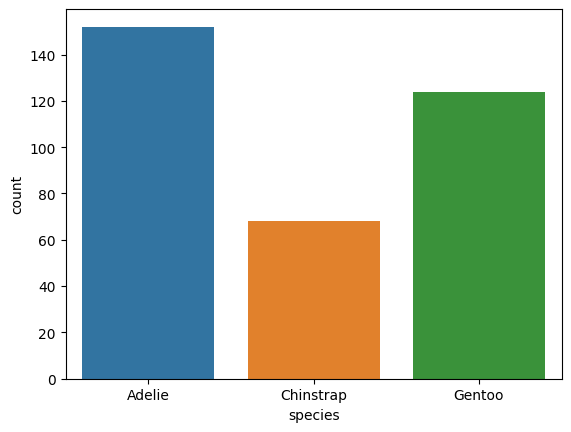

In [11]:
sns.barplot(data=pengo, x="species", y="count", hue="species", estimator="sum")

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size', 'count'], dtype='object')


<Axes: xlabel='sex', ylabel='count'>

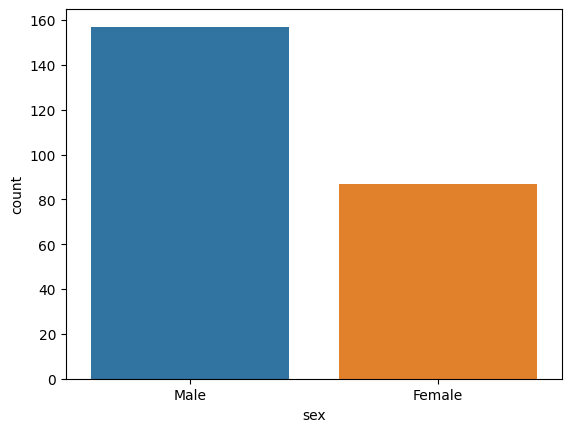

In [15]:
# PROMPT 1
# Are there more males or females in the tips dataset?
print(tips.columns)
sns.barplot(data=tips, x="sex", y="count", estimator="sum", hue="sex")

<Axes: xlabel='count', ylabel='smoker'>

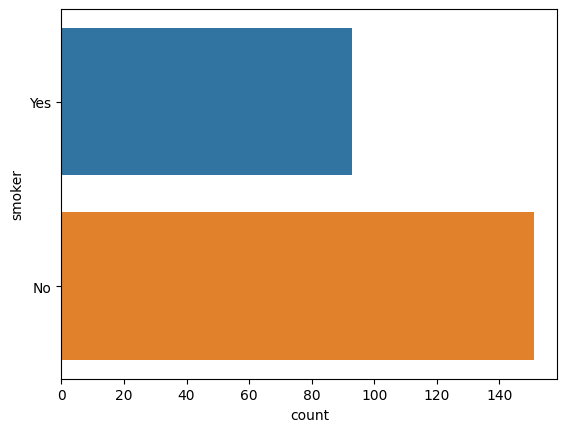

In [17]:
# PROMPT 2
# Are there more smokers or non-smokers in the tips dataset?
# show as a horizontal bar
sns.barplot(data=tips, y="smoker", x="count", estimator="sum", hue="smoker" )

## Bar Plots: Averages

This code displays the average penguin mass by species. The default `estimator='mean'`

<Axes: xlabel='species', ylabel='body_mass_g'>

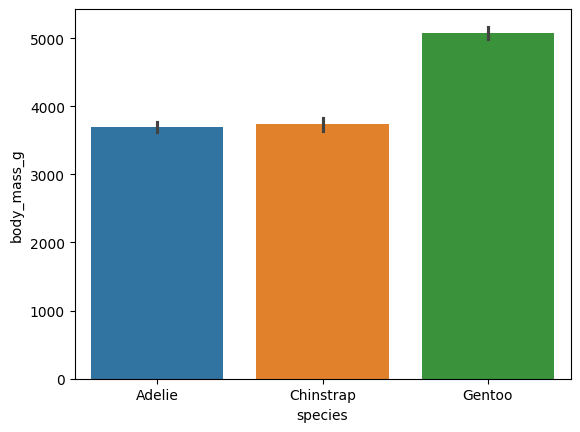

In [16]:
sns.barplot(data=pengo, x="species", y="body_mass_g", hue="species")

<Axes: xlabel='sex', ylabel='tip'>

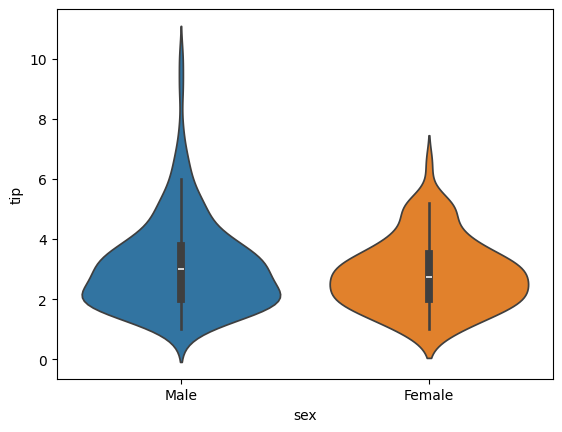

In [29]:
# PROMPT 3
# What is the average tip by gender?
#sns.barplot(data=tips, x="sex", y="tip", hue="sex", estimator="mean", errorbar=("ci", 95))
#sns.boxplot(data=tips, x="sex", y="tip", hue="sex",)
sns.violinplot(data=tips, x="sex", y="tip", hue="sex",)


In [ ]:
# PROMPT 4
# Who tips more smokers or non-smokers?
#skip 

## Adding a Series to a bar plot

This code breaks down the penguin species mass by island. Which island has the most penguins? which species is dominant on each island?

<Axes: xlabel='species', ylabel='count'>

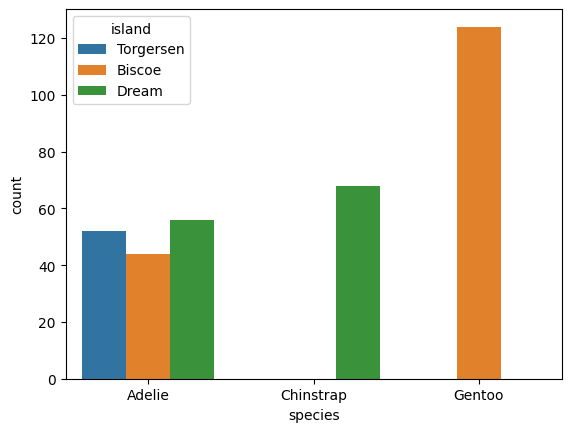

In [32]:
sns.barplot(data=pengo, x="species", y="count", hue="island", estimator="sum")

<Axes: xlabel='smoker', ylabel='count'>

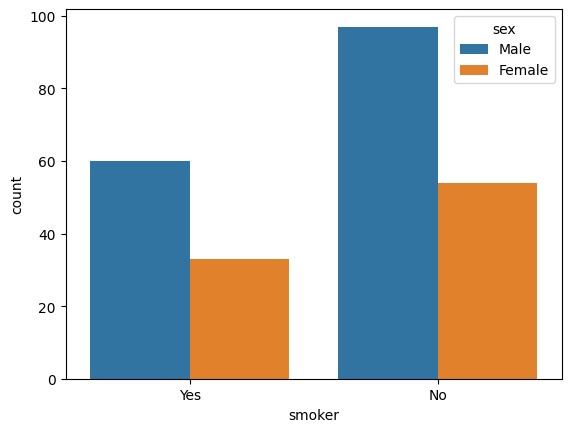

In [35]:
# PROMPT 5
# get a count of tips by sex and smoker
sns.barplot(data = tips, x = "smoker", hue="sex", y="count", estimator="sum")



In [ ]:
# PROMPT 6
# get a count of tips by day and time. Explain why the data appears as it does!


In [36]:
pengo.sample()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,count
317,Gentoo,Biscoe,46.9,14.6,222.0,4875.0,Female,1


In [37]:
tips.sample()

,total_bill,tip,sex,smoker,day,time,size,count
126,8.52,1.48,Male,No,Thur,Lunch,2,1


## Scatter plots

What is the relationship between flipper length and bill length by species!

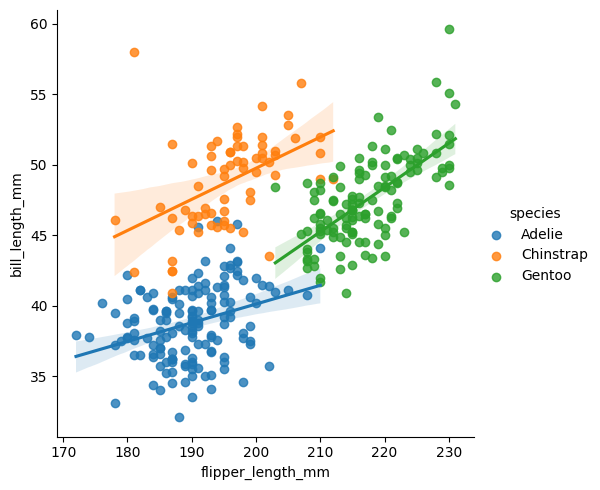

In [41]:
sns.lmplot(data=pengo, x="flipper_length_mm", y="bill_length_mm", hue="species")

<Axes: xlabel='total_bill', ylabel='tip'>

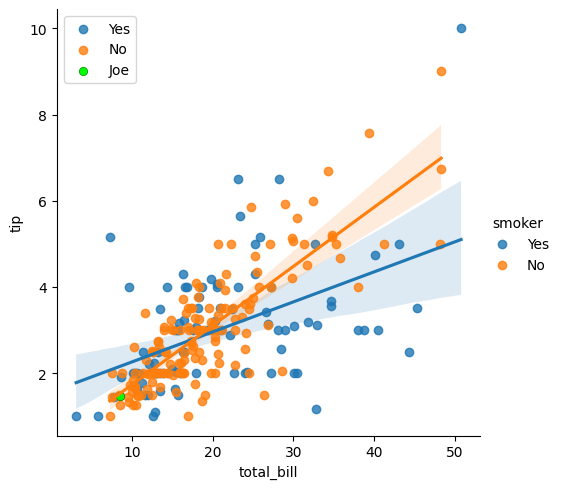

In [53]:
# PROMPT 7
# Show the relationship between bill and tip by gender
sns.lmplot(data=tips, x="total_bill", y="tip", hue="smoker")
joe = tips[126:127]
joe
sns.scatterplot(joe, x="total_bill", y="tip", color="lime", edgecolor="green", label="Joe")

In [ ]:
# PROMPT 8
# Show the relationship between bill and tip by smoker
# skip

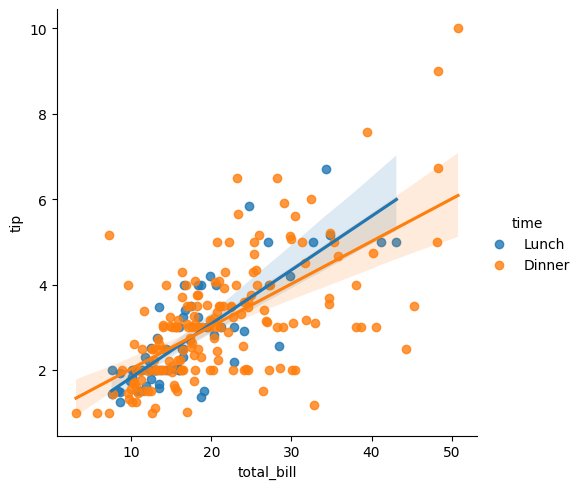

In [56]:
# PROMPT 9
# Show the relationship between bill and tip by lunch/dinner
sns.lmplot(data=tips, x="total_bill", y="tip", hue="time")

In [54]:
pengo.sample()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,count
120,Adelie,Torgersen,36.2,17.2,187.0,3150.0,Female,1


In [55]:
tips.sample()

,total_bill,tip,sex,smoker,day,time,size,count
216,28.15,3.0,Male,Yes,Sat,Dinner,5,1


In [57]:
tips['size'].value_counts()

size
2    156
3     38
4     37
5      5
1      4
6      4
Name: count, dtype: int64

In [58]:
tips[ tips['size'] == 1 ]

,total_bill,tip,sex,smoker,day,time,size,count
67,3.07,1.00,Female,Yes,Sat,Dinner,1,1
82,10.07,1.83,Female,No,Thur,Lunch,1,1
111,7.25,1.00,Female,No,Sat,Dinner,1,1
222,8.58,1.92,Male,Yes,Fri,Lunch,1,1


In [59]:
tips.sort_values("tip").tail(10)

,total_bill,tip,sex,smoker,day,time,size,count
88,24.71,5.85,Male,No,Thur,Lunch,2,1
239,29.03,5.92,Male,No,Sat,Dinner,3,1
47,32.40,6.00,Male,No,Sun,Dinner,4,1
183,23.17,6.50,Male,Yes,Sun,Dinner,4,1
214,28.17,6.50,Female,Yes,Sat,Dinner,3,1
141,34.30,6.70,Male,No,Thur,Lunch,6,1
59,48.27,6.73,Male,No,Sat,Dinner,4,1
23,39.42,7.58,Male,No,Sat,Dinner,4,1
212,48.33,9.00,Male,No,Sat,Dinner,4,1
170,50.81,10.00,Male,Yes,Sat,Dinner,3,1


In [60]:
tips['ratio'] =  tips['tip']  / tips['total_bill']

In [61]:
tips.sort_values('ratio').tail(10)

,total_bill,tip,sex,smoker,day,time,size,count,ratio
51,10.29,2.60,Female,No,Sun,Dinner,2,1,0.252672
221,13.42,3.48,Female,Yes,Fri,Lunch,2,1,0.259314
93,16.32,4.30,Female,Yes,Fri,Dinner,2,1,0.263480
149,7.51,2.00,Male,No,Thur,Lunch,2,1,0.266312
109,14.31,4.00,Female,Yes,Sat,Dinner,2,1,0.279525
183,23.17,6.50,Male,Yes,Sun,Dinner,4,1,0.280535
232,11.61,3.39,Male,No,Sat,Dinner,2,1,0.291990
67,3.07,1.00,Female,Yes,Sat,Dinner,1,1,0.325733
178,9.60,4.00,Female,Yes,Sun,Dinner,2,1,0.416667
172,7.25,5.15,Male,Yes,Sun,Dinner,2,1,0.710345


In [62]:
tips.describe()

,total_bill,tip,size,count,ratio
count,244.000000,244.000000,244.000000,244.0,244.000000
mean,19.785943,2.998279,2.569672,1.0,0.160803
std,8.902412,1.383638,0.951100,0.0,0.061072
min,3.070000,1.000000,1.000000,1.0,0.035638
25%,13.347500,2.000000,2.000000,1.0,0.129127
50%,17.795000,2.900000,2.000000,1.0,0.154770
75%,24.127500,3.562500,3.000000,1.0,0.191475
max,50.810000,10.000000,6.000000,1.0,0.710345


## Interact Example

This example allows the user to select two variables to compare from the following:

`['bill_length_mm;', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']`

it will then compare them using an `lmplot()` for each species. 


In [64]:
choices = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categories = ['species', 'island', 'sex']

@interact_manual(x=choices, y=choices, hue=categories)
def onclick(x, y, hue):
    sns.lmplot(data=pengo, x=x, y=y, hue=hue, markers=".")

interactive(children=(Dropdown(description='x', options=('bill_length_mm', 'bill_depth_mm', 'flipper_length_mm…

### Prompt 10: Interact for tips

Among the following 4 Series:  

`['sex', 'smoker', 'day', 'time']`

Plot a bar of average tip `size`, allowing the user to choose which of the 4 series appears on the horizontal axis, and the other as part of the legend. Do not show the error bars


<Axes: xlabel='smoker', ylabel='ratio'>

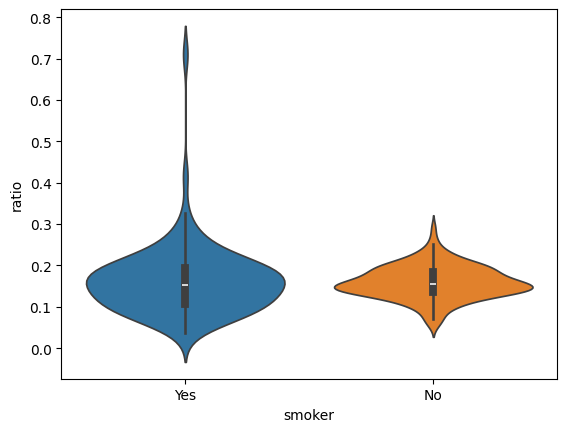

In [65]:
sns.violinplot(data=tips, x = "smoker", y="ratio", hue="smoker")

In [66]:
# PROMPT 10
choices=['sex', 'smoker', 'day', 'time']
@interact_manual(x=choices)
def on_click(x):
    sns.violinplot(data=tips, x=x, y='ratio', hue=x)


interactive(children=(Dropdown(description='x', options=('sex', 'smoker', 'day', 'time'), value='sex'), Button…

## Timeseries Line Plots

Let's take another look at the `health` dataset. The last few challenges will use this dataset. Since it has a `Year` Series, it is suitable for line plots. 

In [67]:
health.sample(5)

,Year,Country,Spending_USD,Life_Expectancy
235,2014,Great Britain,3758.935,81.4
219,2011,USA,8079.467,78.7
238,2015,Canada,4635.285,81.9
41,1980,Japan,535.016,76.1
255,2017,USA,10046.472,78.6


<Axes: xlabel='Year', ylabel='Life_Expectancy'>

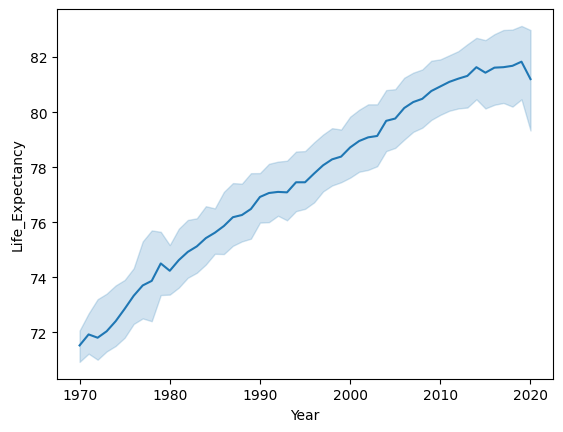

In [68]:
# PROMPT 11
# Plot average life expectancy for all countries by year
sns.lineplot(data=health, x = "Year", y="Life_Expectancy")

<Axes: xlabel='Year', ylabel='Life_Expectancy'>

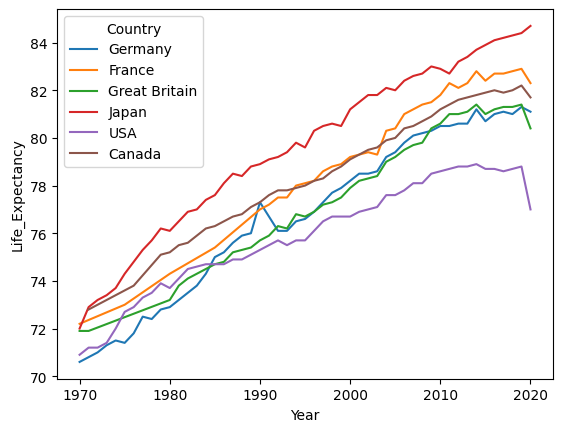

In [69]:
# PROMPT 12
# # Plot average life expectancy by year, broken our for each country as a legend
sns.lineplot(data=health, x="Year", y="Life_Expectancy", hue="Country")

## Final Plot

Figure out the best way to plot this:

Compare life expectancy to Spending. Show each country in the legend

<Axes: xlabel='Life_Expectancy', ylabel='Year'>

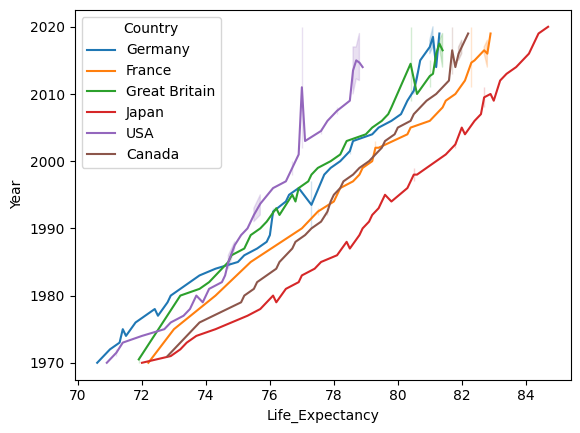

In [72]:
# PROMPT 13 Year	Country	  Spending_USD	   Life_Expectancy
#sns.lineplot(data=health, y="Life_Expectancy", x="Spending_USD", hue="Country")
sns.lineplot(data=health, x="Life_Expectancy", y="Year", hue="Country")

In [ ]:
# run this code to turn in your work!
from casstools.assignment import Assignment
Assignment().submit()

✅ TIMESTAMP  : 2026-04-15 17:00
✅ COURSE     : ist256
✅ TERM       : spring2026
✅ USER       : mafudge@syr.edu
✅ STUDENT    : True
✅ PATH       : ist256/spring2026/lessons/12-Visualization/SmallGroup-Visualization.ipynb
✅ ASSIGNMENT : SmallGroup-Visualization.ipynb
✅ POINTS     : 3
✅ DUE DATE   : 2026-04-15 23:59
✅ LATE       : False
✅ STATUS     : New Submission



❓ Submit? [y/n] ❓  y
